## ResNet50

In [10]:
import os   ### For working of CUDA #

# Disable XLA completely
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/local/cuda"
os.environ["TF_DISABLE_XLA"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [17]:
import tensorflow as tf
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score
import matplotlib.pyplot as plt

# Mixed precision for GPU efficiency (optional)
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

IMG_SIZE = 224
BATCH_SIZE = 8   # reduce to 4 if OOM
AUTOTUNE = tf.data.AUTOTUNE

BASE = Path().resolve().parents[0]
MANIFEST = BASE / "data/processed/manifest.csv"
manifest = pd.read_csv(MANIFEST)


In [18]:
# Data augmentation (TensorFlow ops only)
def augment(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.12)
    image = tf.image.random_contrast(image, 0.85, 1.15)
    image = tf.image.random_saturation(image, 0.9, 1.1)
    
    # Random crop from slightly larger image
    bigger = tf.image.resize(image, [IMG_SIZE + 20, IMG_SIZE + 20])
    image = tf.image.random_crop(bigger, size=[IMG_SIZE, IMG_SIZE, 3])
    return image

def load_and_preprocess(path, label, augment_flag):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)

    if augment_flag:
        image = augment(image)

    image = tf.keras.applications.resnet.preprocess_input(image)
    return image, tf.cast(label, tf.int32)


In [19]:
def make_ds(df, split, shuffle=False, augment=False):
    data = df[df["split"] == split]
    paths = tf.constant(data["image_path"].tolist())
    labels = tf.constant(data["label"].astype(np.int32).tolist())

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(min(len(paths), 10000))

    ds = ds.map(
        lambda p, y: load_and_preprocess(p, y, augment),
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds, data.reset_index(drop=True)

train_ds, train_df = make_ds(manifest, "train", shuffle=True, augment=True)
val_ds,   val_df   = make_ds(manifest, "val")
test_ds,  test_df  = make_ds(manifest, "test")


In [20]:
y_train = train_df["label"].values
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
class_weights


{0: 0.742089210827297, 1: 1.5326771653543307}

In [21]:
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        eps = 1e-7
        y_pred = tf.clip_by_value(y_pred, eps, 1 - eps)
        p_t = tf.where(y_true == 1, y_pred, 1 - y_pred)
        alpha_t = tf.where(y_true == 1, alpha, 1 - alpha)
        return tf.reduce_mean(-alpha_t * (1 - p_t)**gamma * tf.math.log(p_t))
    return loss

LOSS_FN = focal_loss()
# LOSS_FN = tf.keras.losses.BinaryCrossentropy()  # fallback


In [22]:
def build_model():
    base = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    x = tf.keras.layers.Dense(512, activation="relu")(base.output)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    output = tf.keras.layers.Dense(1, activation="sigmoid", dtype="float32")(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)
    return model, base

model, base_model = build_model()
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,639,361 (93.99 MB)

 Trainable params: 24,585,217 (93.79 MB)

 Non-trainable params: 54,144 (211.50 KB)

In [23]:
for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=LOSS_FN,
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)

ckpt1 = tf.keras.callbacks.ModelCheckpoint(
    "best_stage1.h5", monitor="val_auc", mode="max",
    save_best_only=True, verbose=1
)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights,
    callbacks=[ckpt1]
)


Epoch 1/8
2919/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.7401 - auc: 0.5571 - loss: 0.1048

E0000 00:00:1764796631.139328  143443 buffer_comparator.cc:147] Difference at 0: 0.155396, expected -nan
E0000 00:00:1764796631.139366  143443 buffer_comparator.cc:147] Difference at 1: 0.124634, expected 0
E0000 00:00:1764796631.139369  143443 buffer_comparator.cc:147] Difference at 2: 0.205566, expected -nan
E0000 00:00:1764796631.139371  143443 buffer_comparator.cc:147] Difference at 3: 0.140259, expected 0
E0000 00:00:1764796631.139373  143443 buffer_comparator.cc:147] Difference at 4: 0.196289, expected -nan
E0000 00:00:1764796631.139374  143443 buffer_comparator.cc:147] Difference at 5: 0.182617, expected 0
E0000 00:00:1764796631.139376  143443 buffer_comparator.cc:147] Difference at 6: 0.181152, expected -nan
E0000 00:00:1764796631.139378  143443 buffer_comparator.cc:147] Difference at 7: 0.19812, expected 0
E0000 00:00:1764796631.139380  143443 buffer_comparator.cc:147] Difference at 8: 0.136963, expected -nan
E0000 00:00:1764796631.139381  143443 buffer_comparator.cc:147] Diff

2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7401 - auc: 0.5572 - loss: 0.1048

E0000 00:00:1764796714.959529  143444 buffer_comparator.cc:147] Difference at 0: 0.199951, expected -nan
E0000 00:00:1764796714.959569  143444 buffer_comparator.cc:147] Difference at 1: 0.125244, expected 0
E0000 00:00:1764796714.959572  143444 buffer_comparator.cc:147] Difference at 2: 0.204224, expected -nan
E0000 00:00:1764796714.959574  143444 buffer_comparator.cc:147] Difference at 3: 0.199829, expected 0
E0000 00:00:1764796714.959576  143444 buffer_comparator.cc:147] Difference at 4: 0.182129, expected -nan
E0000 00:00:1764796714.959577  143444 buffer_comparator.cc:147] Difference at 5: 0.118286, expected 0
E0000 00:00:1764796714.959579  143444 buffer_comparator.cc:147] Difference at 6: 0.128296, expected -nan
E0000 00:00:1764796714.959582  143444 buffer_comparator.cc:147] Difference at 7: 0.186279, expected 0
E0000 00:00:1764796714.959584  143444 buffer_comparator.cc:147] Difference at 8: 0.0882568, expected -nan
E0000 00:00:1764796714.959586  143444 buffer_comparator.cc:147] Di


Epoch 1: val_auc improved from None to 0.82989, saving model to best_stage1.h5


2920/2920 ━━━━━━━━━━━━━━━━━━━━ 440s 147ms/step - accuracy: 0.7951 - auc: 0.8497 - loss: 0.0723 - val_accuracy: 0.7995 - val_auc: 0.8299 - val_loss: 0.0701
Epoch 2/8
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8627 - auc: 0.6712 - loss: 0.0474
Epoch 2: val_auc improved from 0.82989 to 0.84562, saving model to best_stage1.h5


2920/2920 ━━━━━━━━━━━━━━━━━━━━ 410s 140ms/step - accuracy: 0.8774 - auc: 0.9364 - loss: 0.0374 - val_accuracy: 0.7967 - val_auc: 0.8456 - val_loss: 0.0766
Epoch 3/8
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8809 - auc: 0.6894 - loss: 0.0384
Epoch 3: val_auc did not improve from 0.84562
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 410s 140ms/step - accuracy: 0.8964 - auc: 0.9561 - loss: 0.0290 - val_accuracy: 0.8045 - val_auc: 0.8416 - val_loss: 0.0777
Epoch 4/8
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8992 - auc: 0.6990 - loss: 0.0326
Epoch 4: val_auc did not improve from 0.84562
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 410s 140ms/step - accuracy: 0.9107 - auc: 0.9673 - loss: 0.0244 - val_accuracy: 0.8028 - val_auc: 0.8410 - val_loss: 0.0799
Epoch 5/8
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9144 - auc: 0.7078 - loss: 0.0280
Epoch 5: val_auc improved from 0.84562 to 0.85275, saving model to best_stage1.h5


2920/2920 ━━━━━━━━━━━━━━━━━━━━ 408s 140ms/step - accuracy: 0.9213 - auc: 0.9735 - loss: 0.0220 - val_accuracy: 0.8011 - val_auc: 0.8527 - val_loss: 0.0884
Epoch 6/8
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9170 - auc: 0.7170 - loss: 0.0263
Epoch 6: val_auc did not improve from 0.85275
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 418s 143ms/step - accuracy: 0.9262 - auc: 0.9764 - loss: 0.0208 - val_accuracy: 0.7901 - val_auc: 0.8288 - val_loss: 0.0868
Epoch 7/8
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9260 - auc: 0.7226 - loss: 0.0248
Epoch 7: val_auc did not improve from 0.85275
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 423s 145ms/step - accuracy: 0.9309 - auc: 0.9791 - loss: 0.0195 - val_accuracy: 0.8103 - val_auc: 0.8387 - val_loss: 0.0833
Epoch 8/8
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9231 - auc: 0.7202 - loss: 0.0245
Epoch 8: val_auc did not improve from 0.85275
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 419s 143ms/step - accuracy: 0.9309 - auc: 0.9813 - loss: 

In [24]:
UNFREEZE = 40  # unfreeze last 40 layers (safe for GTX1650)
for layer in base_model.layers[-UNFREEZE:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=LOSS_FN,
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)

ckpt2 = tf.keras.callbacks.ModelCheckpoint(
    "best_resnet_finetuned.h5",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[ckpt2]
)


Epoch 1/20


E0000 00:00:1764799691.684971  143443 buffer_comparator.cc:147] Difference at 0: 5.32812, expected -nan
E0000 00:00:1764799691.685023  143443 buffer_comparator.cc:147] Difference at 1: 5.09375, expected 0
E0000 00:00:1764799691.685025  143443 buffer_comparator.cc:147] Difference at 2: 5.24609, expected -nan
E0000 00:00:1764799691.685027  143443 buffer_comparator.cc:147] Difference at 3: 5.23047, expected 0
E0000 00:00:1764799691.685029  143443 buffer_comparator.cc:147] Difference at 4: 5.26172, expected -nan
E0000 00:00:1764799691.685031  143443 buffer_comparator.cc:147] Difference at 5: 5.32422, expected 0
E0000 00:00:1764799691.685032  143443 buffer_comparator.cc:147] Difference at 6: 5.31641, expected -nan
E0000 00:00:1764799691.685034  143443 buffer_comparator.cc:147] Difference at 7: 5.24609, expected 0
E0000 00:00:1764799691.685036  143443 buffer_comparator.cc:147] Difference at 8: 5.17188, expected -nan
E0000 00:00:1764799691.685037  143443 buffer_comparator.cc:147] Difference a

2919/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7233 - auc: 0.6469 - loss: 0.1008

E0000 00:00:1764800196.967020  143444 buffer_comparator.cc:147] Difference at 0: 5.20312, expected -nan
E0000 00:00:1764800196.967052  143444 buffer_comparator.cc:147] Difference at 1: 5.23438, expected 0
E0000 00:00:1764800196.967055  143444 buffer_comparator.cc:147] Difference at 2: 5.28125, expected -nan
E0000 00:00:1764800196.967056  143444 buffer_comparator.cc:147] Difference at 3: 5.28516, expected 0
E0000 00:00:1764800196.967058  143444 buffer_comparator.cc:147] Difference at 4: 5.16797, expected -nan
E0000 00:00:1764800196.967060  143444 buffer_comparator.cc:147] Difference at 5: 5.28906, expected 0
E0000 00:00:1764800196.967061  143444 buffer_comparator.cc:147] Difference at 6: 5.14062, expected -nan
E0000 00:00:1764800196.967064  143444 buffer_comparator.cc:147] Difference at 7: 5.37109, expected 0
E0000 00:00:1764800196.967066  143444 buffer_comparator.cc:147] Difference at 8: 5.12109, expected -nan
E0000 00:00:1764800196.967067  143444 buffer_comparator.cc:147] Difference a

2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7233 - auc: 0.6470 - loss: 0.1008
Epoch 1: val_auc improved from None to 0.85903, saving model to best_resnet_finetuned.h5


2920/2920 ━━━━━━━━━━━━━━━━━━━━ 606s 198ms/step - accuracy: 0.8275 - auc: 0.9097 - loss: 0.0554 - val_accuracy: 0.8147 - val_auc: 0.8590 - val_loss: 0.0997
Epoch 2/20
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8459 - auc: 0.7070 - loss: 0.0509
Epoch 2: val_auc improved from 0.85903 to 0.90725, saving model to best_resnet_finetuned.h5


2920/2920 ━━━━━━━━━━━━━━━━━━━━ 557s 191ms/step - accuracy: 0.9038 - auc: 0.9621 - loss: 0.0292 - val_accuracy: 0.8531 - val_auc: 0.9073 - val_loss: 0.0639
Epoch 3/20
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9100 - auc: 0.7293 - loss: 0.0323
Epoch 3: val_auc improved from 0.90725 to 0.91186, saving model to best_resnet_finetuned.h5


2920/2920 ━━━━━━━━━━━━━━━━━━━━ 558s 191ms/step - accuracy: 0.9426 - auc: 0.9811 - loss: 0.0196 - val_accuracy: 0.8634 - val_auc: 0.9119 - val_loss: 0.0640
Epoch 4/20
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9488 - auc: 0.7314 - loss: 0.0219
Epoch 4: val_auc improved from 0.91186 to 0.92436, saving model to best_resnet_finetuned.h5


2920/2920 ━━━━━━━━━━━━━━━━━━━━ 556s 190ms/step - accuracy: 0.9646 - auc: 0.9894 - loss: 0.0140 - val_accuracy: 0.8394 - val_auc: 0.9244 - val_loss: 0.0570
Epoch 5/20
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9688 - auc: 0.7426 - loss: 0.0149
Epoch 5: val_auc did not improve from 0.92436
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 561s 192ms/step - accuracy: 0.9749 - auc: 0.9936 - loss: 0.0104 - val_accuracy: 0.8364 - val_auc: 0.9206 - val_loss: 0.0574
Epoch 6/20
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9808 - auc: 0.7440 - loss: 0.0113
Epoch 6: val_auc did not improve from 0.92436
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 536s 184ms/step - accuracy: 0.9800 - auc: 0.9936 - loss: 0.0094 - val_accuracy: 0.8467 - val_auc: 0.9051 - val_loss: 0.0579
Epoch 7/20
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9856 - auc: 0.7441 - loss: 0.0090
Epoch 7: val_auc did not improve from 0.92436
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 538s 184ms/step - accuracy: 0.9833 - auc: 0.9948 - los

2920/2920 ━━━━━━━━━━━━━━━━━━━━ 532s 182ms/step - accuracy: 0.9927 - auc: 0.9975 - loss: 0.0045 - val_accuracy: 0.8302 - val_auc: 0.9325 - val_loss: 0.0831
Epoch 12/20
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9940 - auc: 0.7487 - loss: 0.0048
Epoch 12: val_auc did not improve from 0.93246
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 532s 182ms/step - accuracy: 0.9904 - auc: 0.9952 - loss: 0.0060 - val_accuracy: 0.8176 - val_auc: 0.8909 - val_loss: 0.0916
Epoch 13/20
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9958 - auc: 0.7463 - loss: 0.0044
Epoch 13: val_auc did not improve from 0.93246
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 532s 182ms/step - accuracy: 0.9928 - auc: 0.9966 - loss: 0.0046 - val_accuracy: 0.8383 - val_auc: 0.9110 - val_loss: 0.0842
Epoch 14/20
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9967 - auc: 0.7445 - loss: 0.0037
Epoch 14: val_auc did not improve from 0.93246
2920/2920 ━━━━━━━━━━━━━━━━━━━━ 532s 182ms/step - accuracy: 0.9929 - auc: 0.9975

In [ ]:
model = tf.keras.models.load_model("best_resnet_finetuned.h5",
                                   custom_objects={"loss": LOSS_FN})

y_true = []
y_prob = []

for x, y in test_ds:
    y_true.append(y.numpy())
    y_prob.append(model.predict(x, verbose=0).ravel())

y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)
y_pred = (y_prob >= 0.3).astype(int)            ## Changed from 0.5 to 0.3 

print("Frame-level AUC:", roc_auc_score(y_true, y_prob))
print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))


Frame-level AUC: 0.8909275475115372
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      3196
           1       0.79      0.66      0.72      1711

    accuracy                           0.82      4907
   macro avg       0.81      0.78      0.79      4907
weighted avg       0.82      0.82      0.82      4907

[[2903  293]
 [ 583 1128]]


In [ ]:
test_df["prob"] = y_prob

video_probs = test_df.groupby("video_id")["prob"].mean()
video_labels = test_df.groupby("video_id")["label"].first()

video_preds = (video_probs >= 0.3).astype(int)          ## changed from 0.5 to 0.3

print("Video-level Accuracy:", accuracy_score(video_labels, video_preds))
print("Video-level F1:", f1_score(video_labels, video_preds))
print(classification_report(video_labels, video_preds))
print(confusion_matrix(y_true, y_pred))


Video-level Accuracy: 0.8979591836734694
Video-level F1: 0.8387096774193549
              precision    recall  f1-score   support

           0       0.89      0.97      0.93        32
           1       0.93      0.76      0.84        17

    accuracy                           0.90        49
   macro avg       0.91      0.87      0.88        49
weighted avg       0.90      0.90      0.90        49

[[2903  293]
 [ 583 1128]]


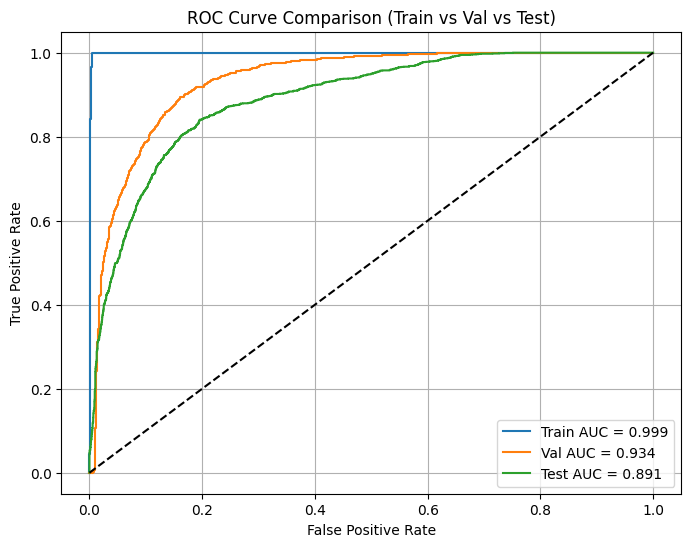

Train AUC: 0.9988775683443687
Val AUC: 0.9338697399812483
Test AUC: 0.8909275475115372


In [34]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def get_probs(ds, model):
    y_true = []
    y_prob = []
    for x, y in ds:
        y_true.append(y.numpy())
        y_prob.append(model.predict(x, verbose=0).ravel())
    return np.concatenate(y_true), np.concatenate(y_prob)

# Load best model again (safe)
model = tf.keras.models.load_model(
    "best_resnet_finetuned.h5",
    custom_objects={"loss": LOSS_FN}
)

# Collect probabilities
y_train_true, y_train_prob = get_probs(train_ds, model)
y_val_true,   y_val_prob   = get_probs(val_ds, model)
y_test_true,  y_test_prob  = get_probs(test_ds, model)

# Compute ROC curves
fpr_train, tpr_train, _ = roc_curve(y_train_true, y_train_prob)
fpr_val,   tpr_val,   _ = roc_curve(y_val_true, y_val_prob)
fpr_test,  tpr_test,  _ = roc_curve(y_test_true, y_test_prob)

auc_train = auc(fpr_train, tpr_train)
auc_val   = auc(fpr_val,   tpr_val)
auc_test  = auc(fpr_test,  tpr_test)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.3f}")
plt.plot(fpr_val,   tpr_val,   label=f"Val AUC = {auc_val:.3f}")
plt.plot(fpr_test,  tpr_test,  label=f"Test AUC = {auc_test:.3f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Train vs Val vs Test)")
plt.legend()
plt.grid(True)
plt.show()

print("Train AUC:", auc_train)
print("Val AUC:", auc_val)
print("Test AUC:", auc_test)


Best threshold on VAL by F1 = 0.160 (val F1 0.784)
FRAME-LEVEL METRICS (threshold = 0.300)
TRAIN: {'accuracy': 0.9959756828495591, 'precision': 0.9879408713692946, 'recall': 0.9998687664041995, 'f1': 0.993869032089747, 'auc': 0.9988391938998474}
VAL  : {'accuracy': 0.8610820973469814, 'precision': 0.8366972477064221, 'recall': 0.6518942101501072, 'f1': 0.732824427480916, 'auc': 0.9338697399812483}
TEST : {'accuracy': 0.8214795190544121, 'precision': 0.7938071780436312, 'recall': 0.6592635885447107, 'f1': 0.7203065134099617, 'auc': 0.8909275475115372}

VIDEO-LEVEL METRICS (threshold = 0.300)
TRAIN: {'accuracy': 0.7522123893805309, 'precision': 0.5725190839694656, 'recall': 1.0, 'f1': 0.7281553398058253, 'auc': 0.8994260485651213}
VAL  : {'accuracy': 0.8775510204081632, 'precision': 0.9166666666666666, 'recall': 0.6875, 'f1': 0.7857142857142857, 'auc': 0.9659090909090908}
TEST : {'accuracy': 0.8979591836734694, 'precision': 0.9285714285714286, 'recall': 0.7647058823529411, 'f1': 0.838709

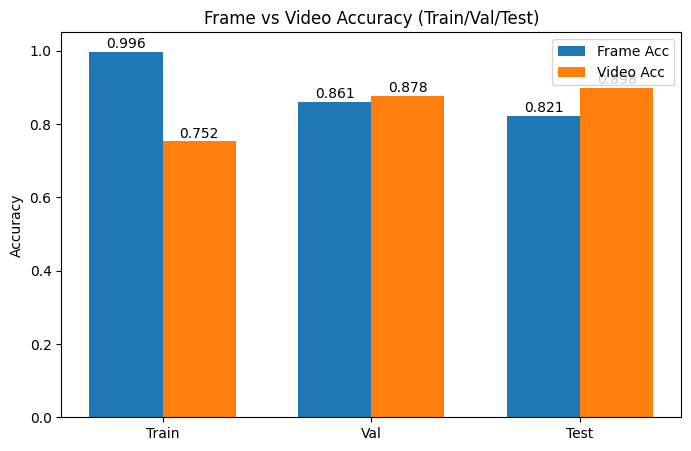

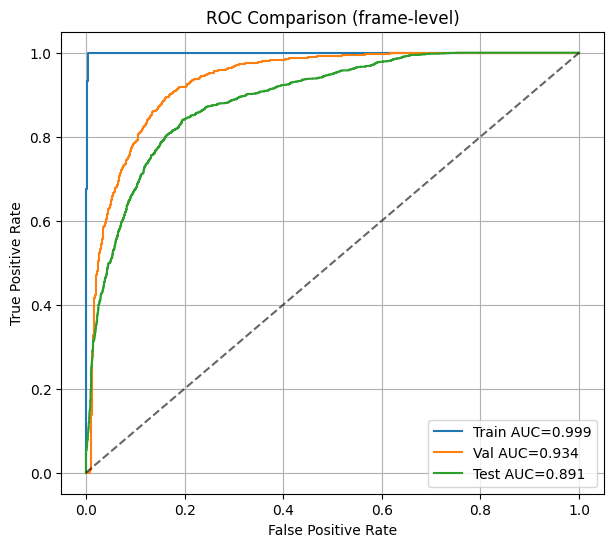

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve
from sklearn.metrics import confusion_matrix
import tensorflow as tf

# helper to get probs + true labels from a tf.data dataset
def get_probs_and_labels(ds, model):
    y_true_parts, y_prob_parts = [], []
    for x_batch, y_batch in ds:
        probs = model.predict(x_batch, verbose=0).ravel()
        y_prob_parts.append(probs)
        y_true_parts.append(y_batch.numpy())
    if len(y_prob_parts) == 0:
        return np.array([]), np.array([])
    y_prob = np.concatenate(y_prob_parts)
    y_true = np.concatenate(y_true_parts)
    return y_true, y_prob

# load best model
model = tf.keras.models.load_model("best_resnet_finetuned.h5", compile=False)  # compile not needed for predict

# get probs+labels for each split
y_train_true, y_train_prob = get_probs_and_labels(train_ds, model)
y_val_true,   y_val_prob   = get_probs_and_labels(val_ds, model)
y_test_true,  y_test_prob  = get_probs_and_labels(test_ds, model)

# function to compute frame-level metrics at a threshold
def frame_metrics(y_true, y_prob, threshold=0.5):
    if len(y_true)==0:
        return {}
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob)
    }

# choose threshold (you found 0.3 worked well; compute best on val too)
def find_best_threshold(y_true, y_prob, metric="f1"):
    threshs = np.linspace(0.05, 0.95, 91)
    best_t, best_score = 0.5, -1
    for t in threshs:
        ypred = (y_prob >= t).astype(int)
        if metric=="f1":
            s = f1_score(y_true, ypred, zero_division=0)
        elif metric=="precision":
            s = precision_score(y_true, ypred, zero_division=0)
        elif metric=="recall":
            s = recall_score(y_true, ypred, zero_division=0)
        else:
            s = f1_score(y_true, ypred, zero_division=0)
        if s > best_score:
            best_score = s
            best_t = t
    return best_t, best_score

best_t, best_f1 = find_best_threshold(y_val_true, y_val_prob, metric="f1")
print(f"Best threshold on VAL by F1 = {best_t:.3f} (val F1 {best_f1:.3f})")

# You can pick threshold = best_t or your manual 0.3
TH = 0.3  # or TH = 0.3                 ## Again chose the 0.3 over best 

# frame-level metrics
frame_train = frame_metrics(y_train_true, y_train_prob, TH)
frame_val   = frame_metrics(y_val_true,   y_val_prob,   TH)
frame_test  = frame_metrics(y_test_true,  y_test_prob,  TH)

print("FRAME-LEVEL METRICS (threshold = {:.3f})".format(TH))
print("TRAIN:", frame_train)
print("VAL  :", frame_val)
print("TEST :", frame_test)

# video-level aggregation and metrics
def video_level_metrics(df_split, y_prob, threshold=0.5):
    # df_split must be aligned in the SAME order as the dataset used; our make_ds used manifest rows order,
    # so train_df / val_df / test_df we returned earlier are aligned to the datasets.
    df = df_split.copy()
    df['prob'] = y_prob
    # mean prob per video
    video_probs = df.groupby('video_id')['prob'].mean()
    video_labels = df.groupby('video_id')['label'].first().astype(int)
    video_pred = (video_probs >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(video_labels, video_pred),
        "precision": precision_score(video_labels, video_pred, zero_division=0),
        "recall": recall_score(video_labels, video_pred, zero_division=0),
        "f1": f1_score(video_labels, video_pred, zero_division=0),
        "auc": roc_auc_score(video_labels.values, video_probs.values)
    }, video_probs, video_labels, video_pred

vid_train_metrics, train_video_probs, train_video_labels, train_video_pred = video_level_metrics(train_df, y_train_prob, threshold=TH)
vid_val_metrics,   val_video_probs,   val_video_labels,   val_video_pred   = video_level_metrics(val_df,   y_val_prob,   threshold=TH)
vid_test_metrics,  test_video_probs,  test_video_labels,  test_video_pred  = video_level_metrics(test_df,  y_test_prob,  threshold=TH)

print("\nVIDEO-LEVEL METRICS (threshold = {:.3f})".format(TH))
print("TRAIN:", vid_train_metrics)
print("VAL  :", vid_val_metrics)
print("TEST :", vid_test_metrics)

# Plot bar chart comparison: frame vs video accuracies across splits
labels = ["Train", "Val", "Test"]
frame_accs = [frame_train.get('accuracy',0), frame_val.get('accuracy',0), frame_test.get('accuracy',0)]
video_accs = [vid_train_metrics.get('accuracy',0), vid_val_metrics.get('accuracy',0), vid_test_metrics.get('accuracy',0)]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, frame_accs, width, label='Frame Acc')
ax.bar(x + width/2, video_accs, width, label='Video Acc')
ax.set_ylabel('Accuracy')
ax.set_title('Frame vs Video Accuracy (Train/Val/Test)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
for i, v in enumerate(frame_accs):
    ax.text(i - width/2, v + 0.01, f"{v:.3f}", ha='center')
for i, v in enumerate(video_accs):
    ax.text(i + width/2, v + 0.01, f"{v:.3f}", ha='center')
plt.ylim(0,1.05)
plt.show()

# Plot ROC curves (frame-level) for Train/Val/Test
fpr_t, tpr_t, _ = roc_curve(y_train_true, y_train_prob)
fpr_v, tpr_v, _ = roc_curve(y_val_true,   y_val_prob)
fpr_te, tpr_te, _ = roc_curve(y_test_true, y_test_prob)
auc_t = roc_auc_score(y_train_true, y_train_prob)
auc_v = roc_auc_score(y_val_true, y_val_prob)
auc_te = roc_auc_score(y_test_true, y_test_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr_t, tpr_t, label=f"Train AUC={auc_t:.3f}")
plt.plot(fpr_v, tpr_v, label=f"Val AUC={auc_v:.3f}")
plt.plot(fpr_te, tpr_te, label=f"Test AUC={auc_te:.3f}")
plt.plot([0,1],[0,1],'k--', alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison (frame-level)")
plt.legend()
plt.grid(True)
plt.show()


In [42]:
model.save("final_resnet_savedmodel.keras")
model.save_weights("final_resnet.weights.h5")
import json
with open("config.json", "w") as f:
    json.dump({"threshold": float(0.3)}, f)  ## can choose between the best threshold or custom i have chosen 0.3
                                                ## to choose best replace 0.3 with "best_t"